# -----------------------------------
# FIFA World Cup 2026 Data Analysis
# Using players.csv
# -----------------------------------

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

In [2]:
df = pd.read_csv("players.csv")
print("Dataset loaded with shape:", df.shape)
print(df.head())

Dataset loaded with shape: (1241, 72)
             player     team team_country position     age  birth_year  \
0      Achref Abada  Algeria      Algeria       DF  27-006        1999   
1     Adil Boulbina  Algeria      Algeria       FW  23-050        2003   
2      Amine Gouiri  Algeria      Algeria       FW  26-125        2000   
3  Anis Hadj Moussa  Algeria      Algeria       MF  24-130        2002   
4       Aïssa Mandi  Algeria      Algeria       DF  34-242        1991   

        club  games  games_starts  minutes  ...  gk_wins  gk_ties  gk_losses  \
0        NaN      0             0      NaN  ...      NaN      NaN        NaN   
1        NaN      1             0     10.0  ...      NaN      NaN        NaN   
2  Marseille      1             1     63.0  ...      NaN      NaN        NaN   
3  Feyenoord      1             1     63.0  ...      NaN      NaN        NaN   
4      Lille      1             1     90.0  ...      NaN      NaN        NaN   

   gk_clean_sheets  gk_clean_sheets_

# -------------------------------
# Step 2: League Mapping
# -------------------------------

league
English Premier League    72
Bundesliga                56
La Liga                   23
Ligue 1                   17
Serie A                   10
Saudi Pro League           8
A-League                   5
Major League Soccer        4
J-League                   1
Name: count, dtype: int64


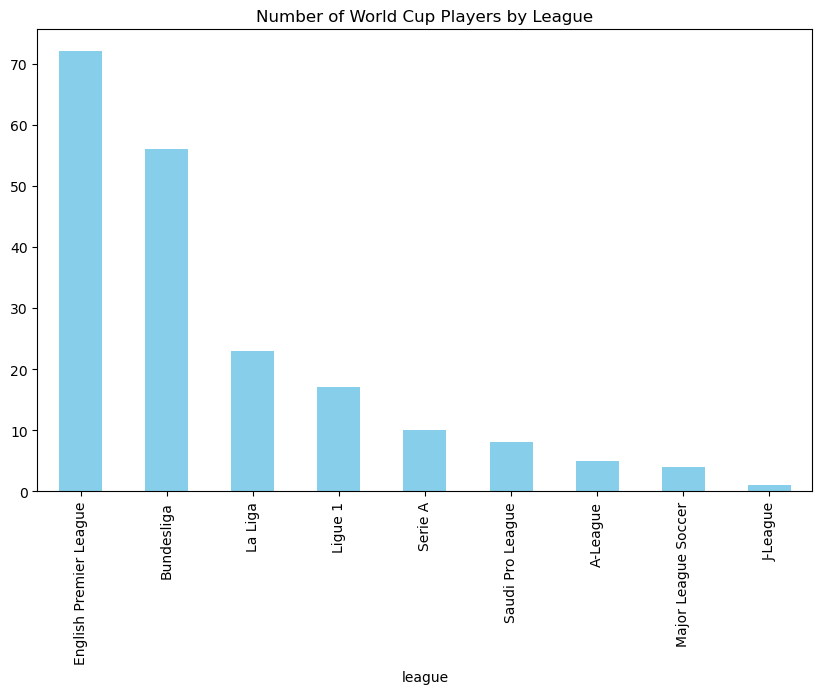

In [3]:
club_league_dict = {
    "Chelsea": "English Premier League",
    "Liverpool": "English Premier League",
    "Manchester City": "English Premier League",
    "Manchester Utd": "English Premier League",
    "Tottenham": "English Premier League",
    "Arsenal": "English Premier League",
    "Aston Villa": "English Premier League",
    "Fulham": "English Premier League",
    "Leicester City": "English Premier League",
    "Real Madrid": "La Liga",
    "Barcelona": "La Liga",
    "Atletico Madrid": "La Liga",
    "Granada": "La Liga",
    "Inter": "Serie A",
    "Napoli": "Serie A",
    "Bayern Munich": "Bundesliga",
    "Dortmund": "Bundesliga",
    "Leverkusen": "Bundesliga",
    "Frankfurt": "Bundesliga",
    "Mainz 05": "Bundesliga",
    "Freiburg": "Bundesliga",
    "RB Leipzig": "Bundesliga",
    "Stuttgart": "Bundesliga",
    "Werder Bremen": "Bundesliga",
    "Lille": "Ligue 1",
    "Nice": "Ligue 1",
    "Marseille": "Ligue 1",
    "Inter Miami": "Major League Soccer",
    "NYCFC": "Major League Soccer",
    "Melb City": "A-League",
    "Melb. Victory": "A-League",
    "Sydney FC": "A-League",
    "Al-Ahli": "Saudi Pro League",
    "Al-Ittihad": "Saudi Pro League",
    "Machida Zelvia": "J-League"
}

df['league'] = df['club'].map(club_league_dict)

# League representation
league_counts = df['league'].value_counts()
print(league_counts)

league_counts.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title("Number of World Cup Players by League")
plt.show()

# -------------------------------
# Step 3: Top Scorers & Playmakers
# -------------------------------

                     player         team             club  goals  assists  \
497             Deniz Undav      Germany        Stuttgart    3.0      2.0   
1062         Alexander Isak       Sweden        Liverpool    1.0      3.0   
217          Jonathan David       Canada         Juventus    3.0      0.0   
177         Vinicius Júnior       Brazil      Real Madrid    2.0      1.0   
621              Ayase Ueda        Japan        Feyenoord    2.0      1.0   
41             Lionel Messi    Argentina      Inter Miami    3.0      0.0   
752              Cody Gakpo  Netherlands        Liverpool    2.0      1.0   
753   Crysencio Summerville  Netherlands         West Ham    2.0      1.0   
806          Erling Haaland       Norway  Manchester City    2.0      0.0   
1084        Viktor Gyökeres       Sweden          Arsenal    1.0      1.0   

      goal_contributions  
497                  5.0  
1062                 4.0  
217                  3.0  
177                  3.0  
621              

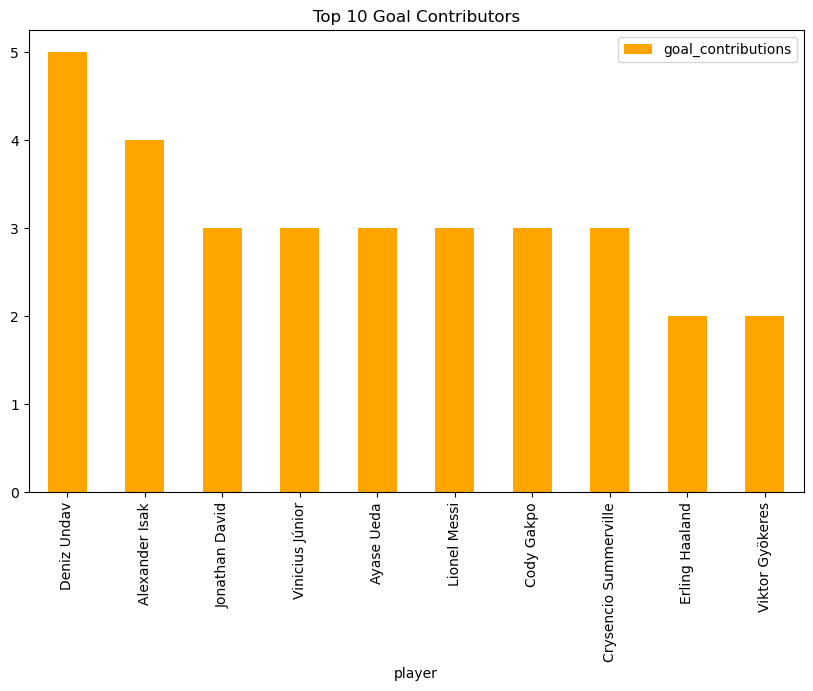

In [4]:
df['goal_contributions'] = df['goals'] + df['assists']
df['goals_per90'] = df['goals'] / df['minutes_90s'].replace(0, pd.NA)
df['assists_per90'] = df['assists'] / df['minutes_90s'].replace(0, pd.NA)
df['contributions_per90'] = df['goal_contributions'] / df['minutes_90s'].replace(0, pd.NA)

top_contributors = df.sort_values(by='goal_contributions', ascending=False).head(10)
print(top_contributors[['player','team','club','goals','assists','goal_contributions']])

top_contributors.plot(x='player', y='goal_contributions', kind='bar', figsize=(10,6), color='orange')
plt.title("Top 10 Goal Contributors")
plt.show()

# -------------------------------
# Step 4: Discipline Analysis
# -------------------------------

              team  cards_yellow  cards_red  total_cards
33        Paraguay           6.0        1.0          7.0
39    South Africa           4.0        2.0          6.0
5   Bosnia & Herz.           5.0        1.0          6.0
35           Qatar           3.0        2.0          5.0
12         Curaçao           5.0        0.0          5.0
21           Haiti           4.0        0.0          4.0
45   United States           4.0        0.0          4.0
37        Scotland           4.0        0.0          4.0
2        Australia           4.0        0.0          4.0
8           Canada           3.0        0.0          3.0
14   Côte d'Ivoire           3.0        0.0          3.0
29     Netherlands           3.0        0.0          3.0
34        Portugal           3.0        0.0          3.0
41          Sweden           3.0        0.0          3.0
26  Korea Republic           3.0        0.0          3.0
6           Brazil           3.0        0.0          3.0
15         Ecuador           2.

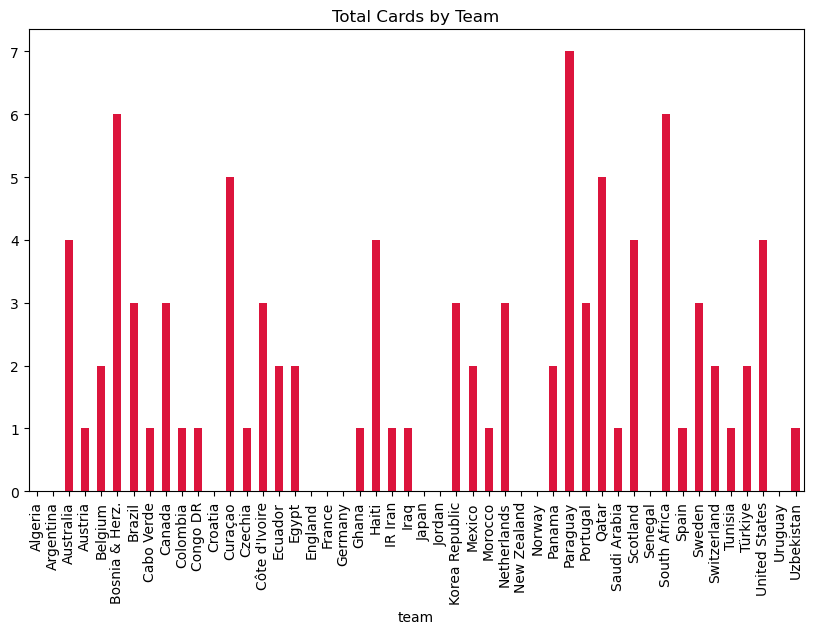

In [5]:
df['cards_total_per90'] = (df['cards_yellow'] + df['cards_red']) / df['minutes_90s'].replace(0, pd.NA)

team_cards = df.groupby('team')[['cards_yellow','cards_red']].sum().reset_index()
team_cards['total_cards'] = team_cards['cards_yellow'] + team_cards['cards_red']
print(team_cards.sort_values(by='total_cards', ascending=False))

team_cards.set_index('team')['total_cards'].plot(kind='bar', figsize=(10,6), color='crimson')
plt.title("Total Cards by Team")
plt.show()

# -------------------------------
# Step 5: Goalkeeper Performance
# -------------------------------

                 player        team           club  gk_minutes  \
1056         Unai Simón       Spain  Athletic Club        90.0   
539   Lawrence Ati-Zigi       Ghana     St. Gallen        45.0   
202             Vozinha  Cabo Verde            NaN        90.0   
523      Benjamin Asare       Ghana            NaN        45.0   
720         Raúl Rangel      Mexico    Guadalajara       180.0   

      gk_goals_against  gk_saves  gk_save_pct  gk_clean_sheets  
1056               0.0       1.0        100.0              1.0  
539                0.0       1.0        100.0              1.0  
202                0.0       7.0        100.0              1.0  
523                0.0       3.0        100.0              1.0  
720                0.0       4.0        100.0              2.0  


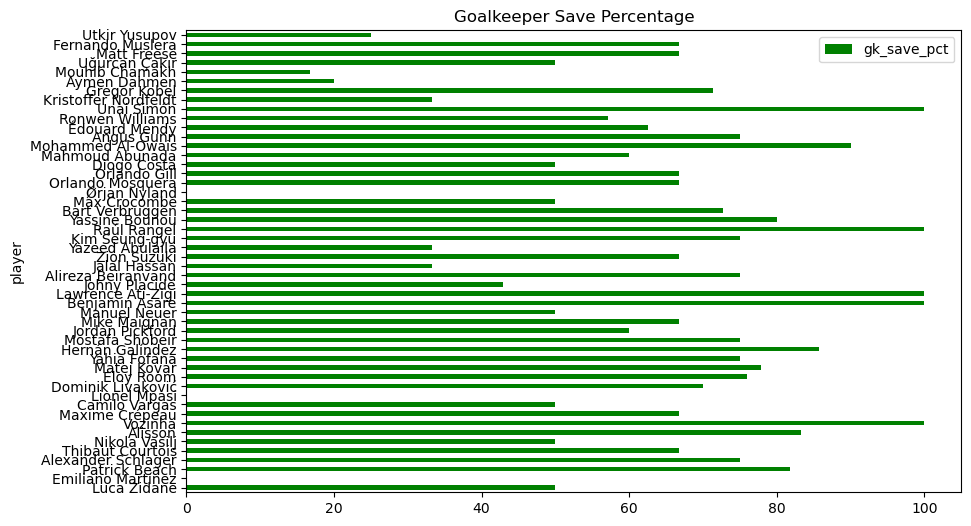

In [6]:
gk_df = df[df['gk_minutes'] > 0].copy()
gk_df['gk_goals_per90'] = gk_df['gk_goals_against'] / gk_df['gk_minutes'] * 90
gk_df['gk_clean_sheet_pct'] = gk_df['gk_clean_sheets'] / gk_df['gk_games'] * 100

top_gks = gk_df.sort_values(by='gk_save_pct', ascending=False).head(5)
print(top_gks[['player','team','club','gk_minutes','gk_goals_against','gk_saves','gk_save_pct','gk_clean_sheets']])

gk_df.plot(x='player', y='gk_save_pct', kind='barh', figsize=(10,6), color='green')
plt.title("Goalkeeper Save Percentage")
plt.show()

# -------------------------------
# Step 6: Age & Experience
# -------------------------------

              team  age_clean
14   Côte d'Ivoire  25.384615
15         Ecuador  25.615385
5   Bosnia & Herz.  26.038462
28         Morocco  26.153846
40           Spain  26.230769
20           Ghana  26.240000
43         Tunisia  26.269231
39    South Africa  26.346154
31          Norway  26.346154
45   United States  26.423077
23            Iraq  26.461538
0          Algeria  26.500000
8           Canada  26.538462
18          France  26.576923
38         Senegal  26.692308
17         England  26.800000
2        Australia  26.884615
24           Japan  26.961538
21           Haiti  27.000000
41          Sweden  27.038462
13         Czechia  27.230769
44         Türkiye  27.230769
4          Belgium  27.360000
29     Netherlands  27.423077
26  Korea Republic  27.500000
27          Mexico  27.538462
12         Curaçao  27.538462
34        Portugal  27.615385
47      Uzbekistan  27.692308
19         Germany  27.692308
30     New Zealand  27.800000
42     Switzerland  27.807692
11        

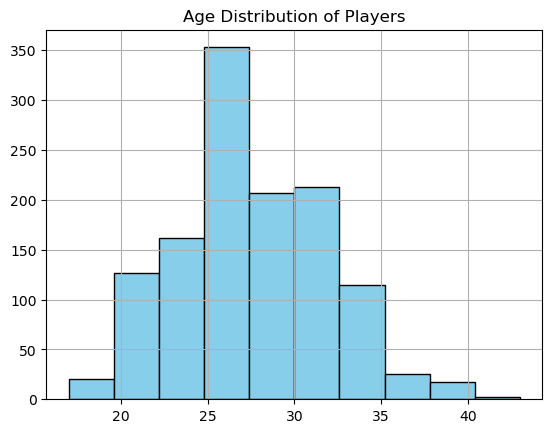

In [7]:
df['age_clean'] = pd.to_numeric(df['age'].astype(str).str.split('-').str[0], errors='coerce')

team_age = df.groupby('team')['age_clean'].mean().reset_index().sort_values(by='age_clean')
print(team_age)

df['age_clean'].dropna().hist(bins=10, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Players")
plt.show()

# -------------------------------
# Step 7: Minutes & Utilization
# -------------------------------

In [8]:
df['minutes_per_game'] = df['minutes'] / df['games'].replace(0, pd.NA)

full_match_players = df[df['minutes'] >= 90]
print("Full match players:\n", full_match_players[['player','team','minutes']].head(10))

impact_subs = df[(df['minutes'] < 30) & (df['goal_contributions'] > 0)]
print("Impact subs:\n", impact_subs[['player','team','minutes','goal_contributions']])

top_minutes = df.sort_values(by='minutes_per_game', ascending=False).head(10)
print("Top minutes per game:\n", top_minutes[['player','team','minutes_per_game']])

Full match players:
                  player       team  minutes
4           Aïssa Mandi    Algeria     90.0
5          Fares Chaïbi    Algeria     90.0
11          Luca Zidane    Algeria     90.0
18       Rafik Belghali    Algeria     90.0
20      Ramy Bensebaini    Algeria     90.0
21      Rayan Aït-Nouri    Algeria     90.0
26  Alexis Mac Allister  Argentina     90.0
28    Emiliano Martínez  Argentina     90.0
29       Enzo Fernández  Argentina     90.0
31       Facundo Medina  Argentina     90.0
Impact subs:
                 player            team  minutes  goal_contributions
139       Ermin Mahmić  Bosnia & Herz.      1.0                 1.0
234              Cucho        Colombia     11.0                 1.0
241    Jaminton Campaz        Colombia     19.0                 1.0
441        Bukayo Saka         England     19.0                 1.0
459    Marcus Rashford         England     19.0                 1.0
467    Bradley Barcola          France     11.0                 1.0
634  

# -------------------------------
# Step 8: Final Summary Insights
# -------------------------------

In [9]:
print("\n===== FINAL SUMMARY =====\n")


===== FINAL SUMMARY =====



# Top scorer

In [10]:
top_scorer = df.sort_values(by='goals', ascending=False).head(1)
print("Top Scorer:", top_scorer['player'].values[0], 
      "-", top_scorer['goals'].values[0], "goals")

Top Scorer: Jonathan David - 3.0 goals


# Top playmaker

In [11]:
top_assist = df.sort_values(by='assists', ascending=False).head(1)
print("Top Playmaker:", top_assist['player'].values[0], 
      "-", top_assist['assists'].values[0], "assists")

Top Playmaker: Alexander Isak - 3.0 assists


# Best goal contributions per 90

In [12]:
top_contrib = df.sort_values(by='contributions_per90', ascending=False).head(1)
print("Most Efficient Contributor:", top_contrib['player'].values[0], 
      "-", round(top_contrib['contributions_per90'].values[0], 2), "contributions per 90")

Most Efficient Contributor: Mattias Svanberg - 10.0 contributions per 90


# Most disciplined team

In [13]:
most_disciplined = team_cards.sort_values(by='total_cards').head(1)
print("Most Disciplined Team:", most_disciplined['team'].values[0], 
      "-", most_disciplined['total_cards'].values[0], "cards")

Most Disciplined Team: Algeria - 0.0 cards


# Most aggressive team

In [14]:
most_aggressive = team_cards.sort_values(by='total_cards', ascending=False).head(1)
print("Most Aggressive Team:", most_aggressive['team'].values[0], 
      "-", most_aggressive['total_cards'].values[0], "cards")

Most Aggressive Team: Paraguay - 7.0 cards


# Best GK (highest save %)

In [15]:
best_gk = gk_df.sort_values(by='gk_save_pct', ascending=False).head(1)
print("Best Goalkeeper:", best_gk['player'].values[0], 
      "-", best_gk['gk_save_pct'].values[0], "% save rate")

Best Goalkeeper: Unai Simón - 100.0 % save rate


# Youngest player

In [16]:
youngest_player = df.sort_values(by='age_clean').head(1)
print("Youngest Player:", youngest_player['player'].values[0], 
      "-", youngest_player['age_clean'].values[0], "years")

Youngest Player: Gilberto Mora - 17 years


# Oldest player

In [17]:
oldest_player = df.sort_values(by='age_clean', ascending=False).head(1)
print("Oldest Player:", oldest_player['player'].values[0], 
      "-", oldest_player['age_clean'].values[0], "years")

Oldest Player: Craig Gordon - 43 years


In [18]:
print("\n===== END OF SUMMARY =====\n")


===== END OF SUMMARY =====

